<a href="https://colab.research.google.com/github/toanhuynh040805-crypto/DeepLearning_DuDoanGiaNha/blob/main/BaiTaoNhomDT1_THDeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Thông tin tổng quan về tập dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

--- Số lượng giá trị bị khuyết trong mỗi cột ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population             

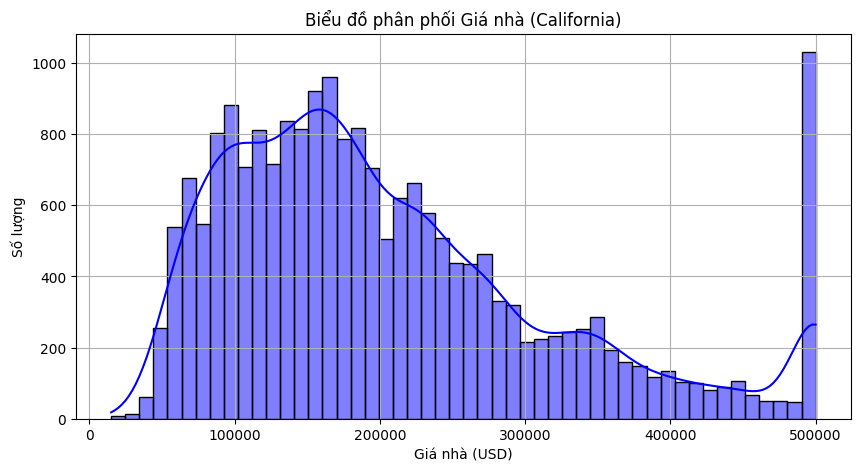

In [16]:
#1: Khám phá & Phân tích dữ liệu (EDA)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('/content/sample_data/housing.csv')

# 2. Xem thông tin tổng quan về các cột và kiểu dữ liệu
print("--- Thông tin tổng quan về tập dữ liệu ---")
print(df.info())

# 3. Kiểm tra số lượng dòng bị khuyết dữ liệu (Missing Values)
print("\n--- Số lượng giá trị bị khuyết trong mỗi cột ---")
print(df.isnull().sum())

# 4. Vẽ biểu đồ phân phối của giá nhà (Biến mục tiêu)
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], kde=True, color='blue', bins=50)
plt.title('Biểu đồ phân phối Giá nhà (California)')
plt.xlabel('Giá nhà (USD)')
plt.ylabel('Số lượng')
plt.grid(True)
plt.show()

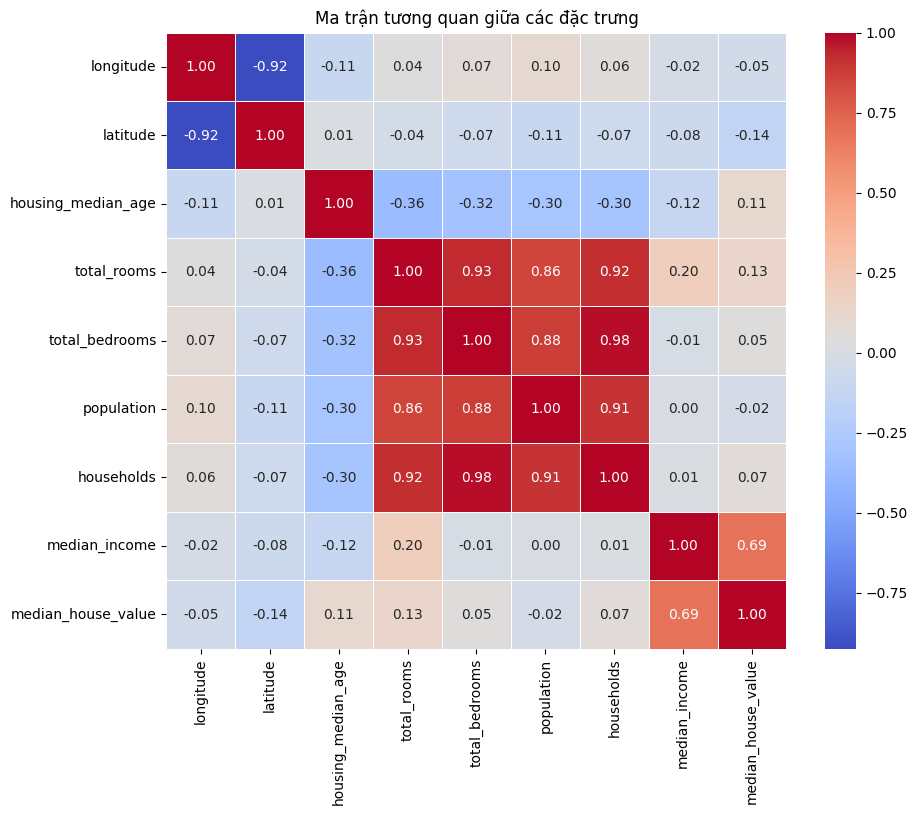

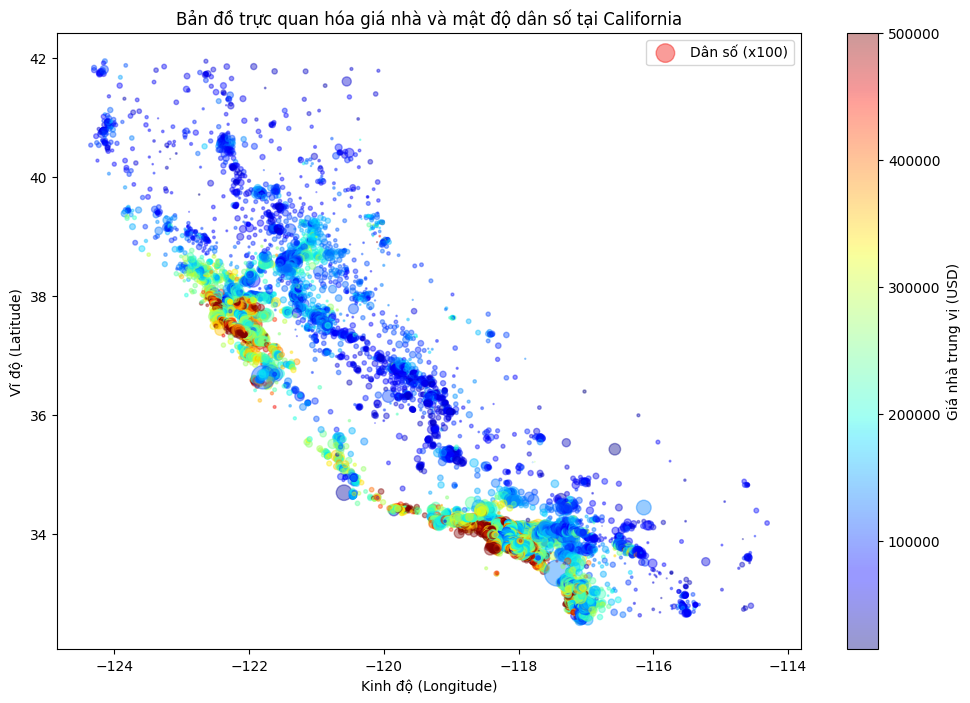

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Added for np.number

# 1. Vẽ Ma trận tương quan (Correlation Matrix)
plt.figure(figsize=(10, 8))
# Chọn chỉ các cột số để tính toán tương quan, bỏ qua các cột chuỗi
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng')
plt.show()

# 2. Vẽ biểu đồ phân bố địa lý của giá nhà theo Tọa độ (Kinh độ/Vĩ độ)
plt.figure(figsize=(12, 8))
sc = plt.scatter(df['longitude'], df['latitude'], alpha=0.4,
                 s=df['population']/100, label='Dân số (x100)',
                 c=df['median_house_value'], cmap=plt.get_cmap('jet'))
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')
plt.title('Bản đồ trực quan hóa giá nhà và mật độ dân số tại California')
plt.legend()
# Đặt tên cho thanh hiển thị màu sắc
cbar = plt.colorbar(sc)
cbar.set_label('Giá nhà trung vị (USD)')
plt.show()

In [18]:
#2: Tiền xử lý dữ liệu (Data Preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Xử lý giá trị khuyết bằng cách điền giá trị trung vị (Median)
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

# 2. Mã hóa biến phân loại 'ocean_proximity' thành các cột số (0 và 1)
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# 3. Tách Đặc trưng (X) và Nhãn/Giá nhà (y)
# Bây giờ X sẽ bao gồm tất cả các cột trừ cột giá nhà 'median_house_value'
X = df.drop(columns=['median_house_value']).values
y = df['median_house_value'].values

# 4. Chia dữ liệu thành tập Huấn luyện (80%) và Kiểm tra (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Chuẩn hóa dữ liệu đầu vào (Standardization)
# Đưa tất cả dữ liệu về cùng một phân phối có trung bình bằng 0, độ lệch chuẩn bằng 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nKích thước tập Train: {X_train_scaled.shape}")
print(f"Kích thước tập Test: {X_test_scaled.shape}")


Kích thước tập Train: (16512, 12)
Kích thước tập Test: (4128, 12)


In [19]:
#3: Thiết kế & Huấn luyện mạng ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Định nghĩa cấu trúc mạng ANN (Giữ nguyên cấu trúc của nhóm)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# 2. Biên dịch mô hình với tốc độ học ban đầu
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='mse',
    metrics=['mae']
)

# 3. ĐỊNH NGHĨA CÁC CALLBACKS NÂNG CAO (Thêm mới)
# Tự động dừng nếu val_loss không giảm sau 10 epoch và giữ lại trọng số tốt nhất
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Tự động giảm một nửa Learning Rate nếu val_loss bị chững lại sau 5 epoch
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

# 4. Huấn luyện mô hình (Tăng epoch lên 150 vì đã có Early Stopping kiểm soát)
print("\n--- Bắt đầu huấn luyện mạng ANN nâng cao ---")
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler], # Kích hoạt Callbacks tại đây
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Bắt đầu huấn luyện mạng ANN nâng cao ---
Epoch 1/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 26200600576.0000 - mae: 121035.1484 - val_loss: 7346870784.0000 - val_mae: 60566.1875 - learning_rate: 0.0020
Epoch 2/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5866501120.0000 - mae: 54333.5156 - val_loss: 5351143424.0000 - val_mae: 51405.3945 - learning_rate: 0.0020
Epoch 3/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4943485440.0000 - mae: 50364.0703 - val_loss: 5031531008.0000 - val_mae: 49902.9492 - learning_rate: 0.0020
Epoch 4/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4676522496.0000 - mae: 48704.5469 - val_loss: 4807749120.0000 - val_mae: 49445.1289 - learning_rate: 0.0020
Epoch 5/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4532037632.0000 - mae: 48043.0898 - val_loss: 4725782528.0000 - val_mae: 48002.0234 - learning_rate: 0.0020
Epoch 6/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4462682624.0000 - mae: 47501.1094 - val_loss: 

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

================ KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ================
1. Mean Absolute Error (MAE): $44,064.98 USD
2. Mean Squared Error (MSE) : 4,075,999,260.68
3. Root Mean Squared Error (RMSE): $63,843.55 USD


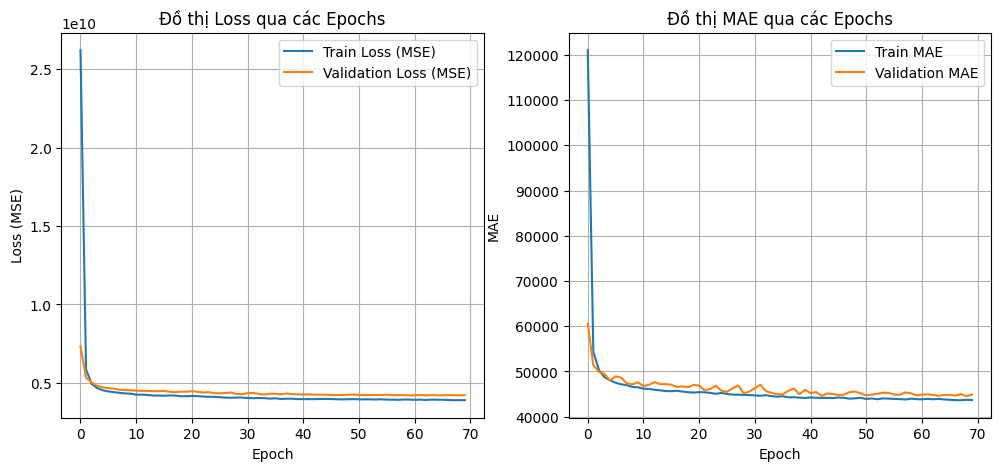

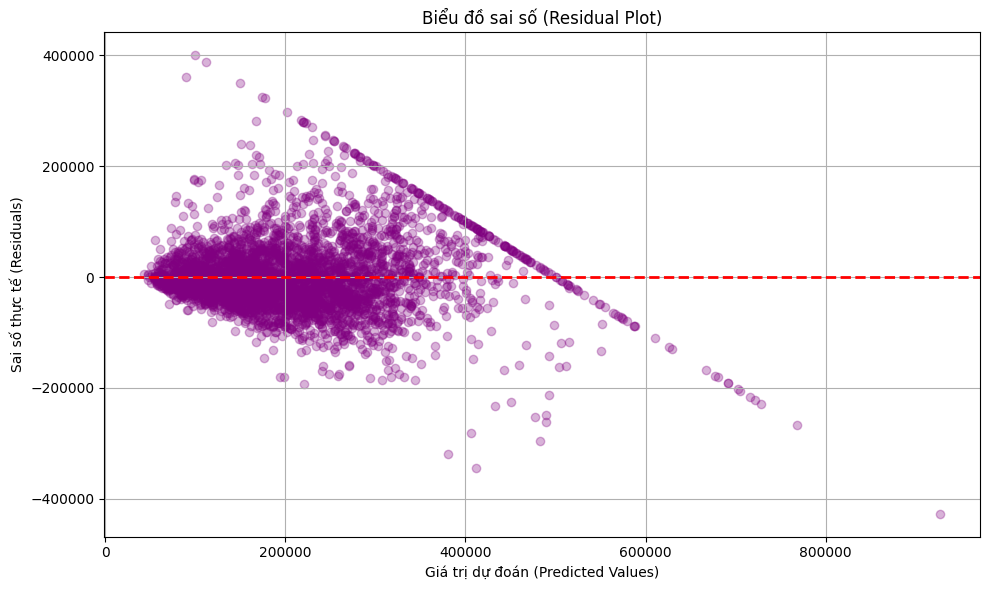


Bảng so sánh ngẫu nhiên 5 kết quả đầu tiên:
 Giá thực tế (USD)  Giá dự đoán (USD)
           47700.0       58407.023438
           45800.0      143773.968750
          500001.0      419187.093750
          218600.0      261494.609375
          278000.0      297088.593750


In [21]:
#4: Đánh giá mô hình & Trực quan hóa kết quả
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Dự đoán trên tập dữ liệu kiểm tra (Test set)
y_pred = model.predict(X_test_scaled).flatten()

# 2. Tính toán các chỉ số lỗi MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n================ KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ================")
print(f"1. Mean Absolute Error (MAE): ${mae:,.2f} USD")
print(f"2. Mean Squared Error (MSE) : {mse:,.2f}")
print(f"3. Root Mean Squared Error (RMSE): ${rmse:,.2f} USD")
print("==========================================================")

# 3. Vẽ đồ thị Lịch sử huấn luyện (Loss Curve)
plt.figure(figsize=(12, 5))

# Đồ thị Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Đồ thị Loss qua các Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Đồ thị MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Đồ thị MAE qua các Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

#BIỂU ĐỒ SAI SỐ (RESIDUAL PLOT)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Biểu đồ sai số (Residual Plot)')
plt.xlabel('Giá trị dự đoán (Predicted Values)')
plt.ylabel('Sai số thực tế (Residuals)')
plt.grid(True)


plt.tight_layout()
plt.show()

# 4. Xuất thử 5 căn nhà thực tế so với dự đoán để kiểm tra trực quan
df_compare = pd.DataFrame({'Giá thực tế (USD)': y_test, 'Giá dự đoán (USD)': y_pred})
print("\nBảng so sánh ngẫu nhiên 5 kết quả đầu tiên:")
print(df_compare.head(5).to_string(index=False))

In [25]:
# ==========================================
# KỊCH BẢN KIỂM THỬ: DỰ ĐOÁN CĂN NHÀ MỚI 100%
# ==========================================

# Giả sử có một căn nhà mới với các thông số đầu vào tương tự như tập dữ liệu:
# [longitude, latitude, housing_median_age, total_rooms, total_bedrooms,
#  population, households, median_income, ocean_proximity_INLAND,
#  ocean_proximity_ISLAND, ocean_proximity_NEAR BAY, ocean_proximity_NEAR OCEAN]
# Lưu ý: Điền đúng số lượng cột (12 cột số) sau khi đã One-Hot Encoding ở Bước 2 và bỏ 1 cột dummy.

# Dữ liệu mẫu ban đầu: [-122.23, 37.88, 41.0, 880.0, 129.0, 322.0, 126.0, 8.3252, 0, 0, 0, 1, 0]
# Với ocean_proximity: <1H OCEAN=0, INLAND=0, ISLAND=0, NEAR BAY=1, NEAR OCEAN=0
# Sau khi get_dummies với drop_first=True, cột 'ocean_proximity_<1H OCEAN' đã bị loại bỏ.
# Do đó, chúng ta cần cung cấp 4 giá trị cho các cột dummy còn lại: INLAND, ISLAND, NEAR BAY, NEAR OCEAN.
new_house_data = np.array([[-122.23, 37.88, 41.0, 880.0, 129.0, 322.0, 126.0, 8.3252, 0, 0, 1, 0]])

# 1. Bắt buộc phải chuẩn hóa dữ liệu mới bằng scaler đã dùng khi train
new_house_scaled = scaler.transform(new_house_data)

# 2. Đưa vào mô hình ANN để dự đoán
predicted_price = model.predict(new_house_scaled)

print("\n================ KẾT QUẢ KIỂM THỬ THỰC TẾ ================")
print(f"Thông số căn nhà thử nghiệm: Thu nhập trung bình cao, nằm ở khu vực NEAR BAY.")
print(f"-> Giá nhà dự đoán từ mạng ANN: ${predicted_price[0][0]:,.2f} USD")
print("==========================================================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step

================ KẾT QUẢ KIỂM THỬ THỰC TẾ ================
Thông số căn nhà thử nghiệm: Thu nhập trung bình cao, nằm ở khu vực NEAR BAY.
-> Giá nhà dự đoán từ mạng ANN: $413,420.75 USD


In [6]:
#Lưu (Export) Mô hình và Bộ chuẩn hóa từ Colab
# Lưu mô hình ANN thành file định dạng Keras (.h5 hoặc .keras)
model.save('ann_house_model.h5')

# Lưu bộ chuẩn hóa dữ liệu StandardScaler (sử dụng thư viện pickle)
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Đã lưu thành công 2 file: 'ann_house_model.h5' và 'scaler.pkl'. Hãy tải chúng về máy tính của bạn!")

Đã lưu thành công 2 file: 'ann_house_model.h5' và 'scaler.pkl'. Hãy tải chúng về máy tính của bạn!


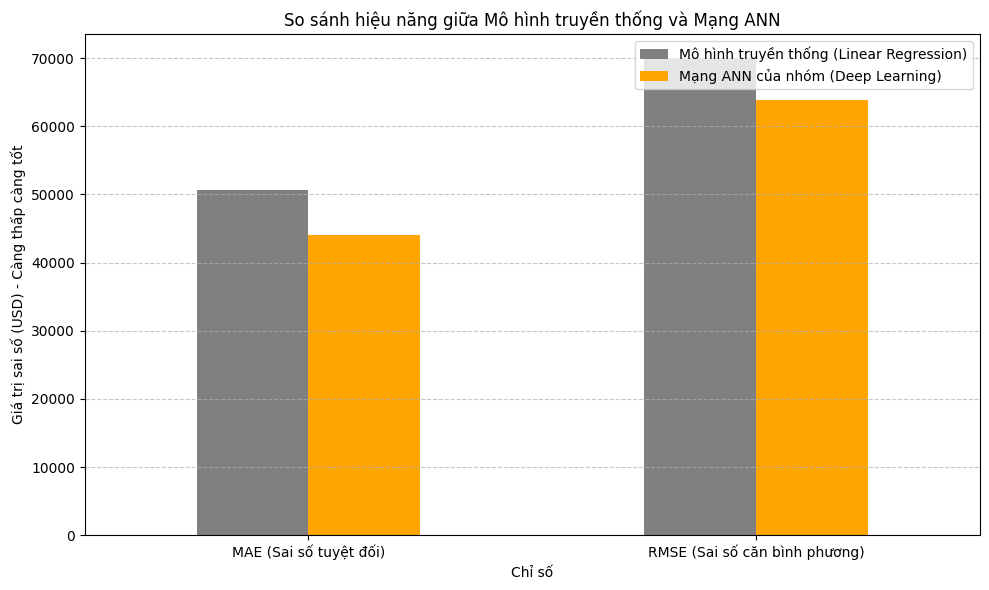


================ BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH ================
Tiêu chí đánh giá         | Linear Regression    | Mạng ANN của nhóm   
------------------------------------------------------------------------
MAE (Sai số trung bình)   | $50,670.74 USD      | $44,064.98 USD
RMSE (Sai số lớn nhất)    | $70,060.52 USD      | $63,843.55 USD
--> Nhận xét: Mạng ANN giúp giảm sai số RMSE khoảng 8.87% so với mô hình truyền thống.


In [26]:
# =====================================================================
# BƯỚC BỔ SUNG NÂNG CAO: SO SÁNH VỚI MÔ HÌNH LUẬT TRUYỀN THỐNG (BASELINE)
# =====================================================================
from sklearn.linear_model import LinearRegression

# 1. Huấn luyện mô hình Linear Regression truyền thống trên cùng tập dữ liệu
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Dự đoán trên tập Test bằng mô hình truyền thống
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. Tính toán sai số của mô hình truyền thống
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# 4. Trực quan hóa so sánh giữa ANN và Linear Regression bằng biểu đồ cột
metrics_data = {
    'Chỉ số': ['MAE (Sai số tuyệt đối)', 'RMSE (Sai số căn bình phương)'],
    'Mô hình truyền thống (Linear Regression)': [mae_lr, rmse_lr],
    'Mạng ANN của nhóm (Deep Learning)': [mae, rmse] # Lấy từ kết quả bước 4 của bạn
}

df_metrics = pd.DataFrame(metrics_data)

# Vẽ biểu đồ so sánh
df_metrics.set_index('Chỉ số').plot(kind='bar', figsize=(10, 6), color=['gray', 'orange'])
plt.title('So sánh hiệu năng giữa Mô hình truyền thống và Mạng ANN')
plt.ylabel('Giá trị sai số (USD) - Càng thấp càng tốt')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 5. In bảng kết quả chi tiết
print("\n================ BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH ================")
print(f"{'Tiêu chí đánh giá':<25} | {'Linear Regression':<20} | {'Mạng ANN của nhóm':<20}")
print("-" * 72)
print(f"{'MAE (Sai số trung bình)':<25} | ${mae_lr:,.2f} USD {'':<4} | ${mae:,.2f} USD")
print(f"{'RMSE (Sai số lớn nhất)':<25} | ${rmse_lr:,.2f} USD {'':<4} | ${rmse:,.2f} USD")
print("=================================================================")

# Tính toán phần trăm cải tiến
improvement = ((rmse_lr - rmse) / rmse_lr) * 100
print(f"--> Nhận xét: Mạng ANN giúp giảm sai số RMSE khoảng {improvement:.2f}% so với mô hình truyền thống.")